# Map visualization

Single-scenario map rendering and the dependent student-observation inspection moved from `scenario_tool.ipynb`.


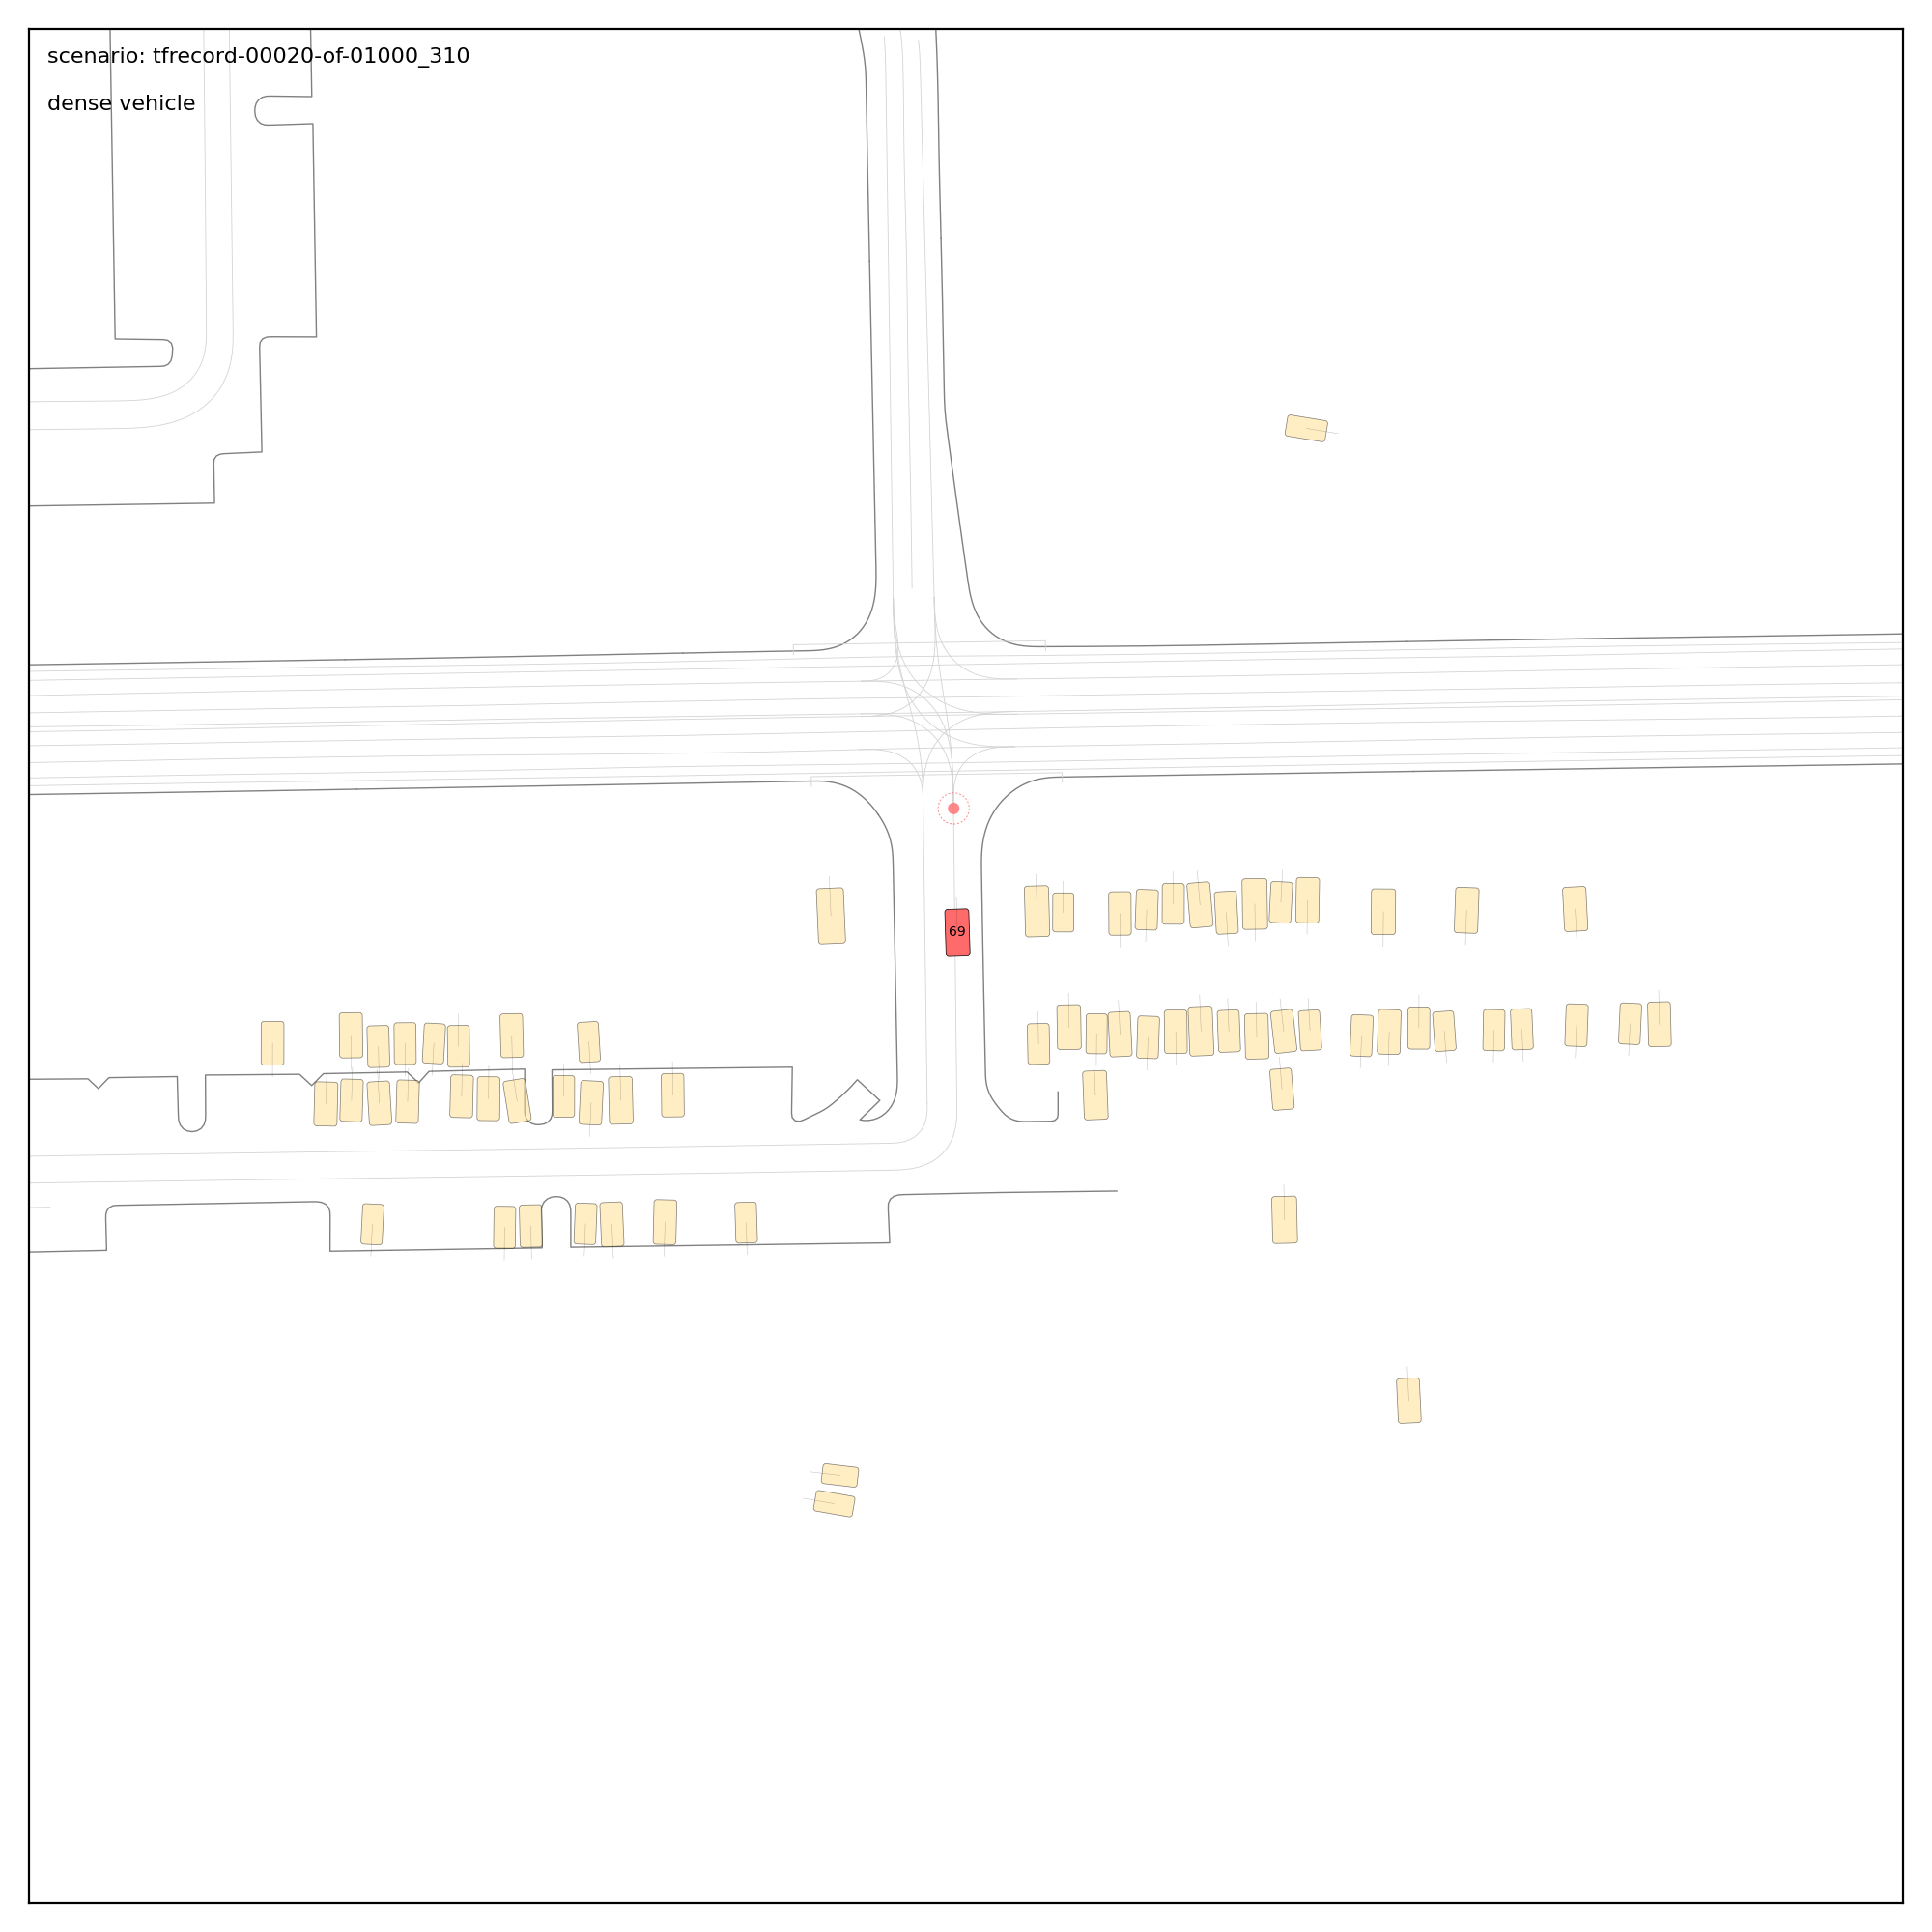

scenario=tfrecord-00020-of-01000_310, ego=69, opponents=[], vehicle_count=68, tilting_mode=per_vehicle, tilting_source=random, tilt_seed=1, show_tilting_number=True, show_gt_trajectory=False, gt_trajectory_style=line, global_tilt=(0, 0, 0), per_vehicle_tilting_head=(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)


In [ ]:
import json
import sys
from pathlib import Path

import numpy as np

from IPython.display import display
from PIL import Image as PILImage

project_root = Path("/home/chen/workspace/dcd-ctrlsim")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from envs.nocturne_ctrlsim.adversarial import NocturneCtrlSimAdversarial
from envs.nocturne_ctrlsim.core.level import ScenarioLevel, build_zero_tilt_level
from envs.nocturne_ctrlsim.utils.tilt_helpers import sample_random_tilt_components

log_dir = Path(
    "/media/chen/Dataset/logs/dcd/steps4096000-proc16-roll256-plr1-edit1-tiltper_vehicle-kl1-prw0_0"
)
meta_path = log_dir / "meta.json"
with meta_path.open("r", encoding="utf-8") as f:
    meta = json.load(f)
args = meta.get("args", meta)

# Modify this scenario_id directly when you want to inspect another scene from this run.
scenario_id = "tfrecord-00023-of-01000_166"
tilting_mode = "per_vehicle"  # Options: "per_vehicle", "global", "none".
show_tilting_number = True
tilting_source = "random"  # Options: "random", "zero".
tilt_seed = 1
show_gt_trajectory = False
gt_trajectory_style = "line"  # Options: "ghost", "line".

env = NocturneCtrlSimAdversarial(
    scenario_index_path=args["scenario_index_path"],
    opponent_checkpoint=args["opponent_checkpoint"],
    scenario_data_dir=args["scenario_data_dir"],
    preprocess_dir=args["preprocess_dir"],
    vehicle_map_path=args["vehicle_map_path"],
    device="cpu",
    tilting_mode=tilting_mode,
    mutation_mode=args["mutation_mode"],
    student_accel_discretization=args["student_accel_discretization"],
    student_steer_discretization=args["student_steer_discretization"],
    obs_dim=None,
    remove_background_vehicles=args["remove_background_vehicles"],
    show_vehicle_ids=True,
    show_tilting_params=show_tilting_number,
    show_ego_vehicle_selection=args["show_ego_vehicle_selection"],
    opponent_runtime_mode=args.get("opponent_runtime_mode") or "normal",
    inference_precision=args.get("inference_precision", "fp32"),
)
if tilting_source == "random" and tilting_mode != "none":
    tilt_rng = np.random.RandomState(tilt_seed)
    goal_tilt, veh_veh_tilt, veh_edge_tilt, per_vehicle_tilting = sample_random_tilt_components(
        tilting_mode=tilting_mode,
        per_vehicle_tilting_length=env.per_vehicle_tilting_length,
        tilt_range=env.tilt_range,
        rng=tilt_rng,
    )
    level = ScenarioLevel(
        scenario_id=scenario_id,
        seed=tilt_seed,
        goal_tilt=goal_tilt,
        veh_veh_tilt=veh_veh_tilt,
        veh_edge_tilt=veh_edge_tilt,
        per_vehicle_tilting=per_vehicle_tilting,
    )
else:
    level = build_zero_tilt_level(
        scenario_id=scenario_id,
        seed=tilt_seed,
        tilting_mode=tilting_mode,
        per_vehicle_tilting_length=env.per_vehicle_tilting_length,
    )
env.reset_to_level(level)
env.show_gt_trajectory = show_gt_trajectory
env.gt_trajectory_style = gt_trajectory_style

render_tilting_mode = "global" if tilting_mode == "none" and show_tilting_number else tilting_mode
original_tilting_mode = env.tilting_mode
env.tilting_mode = render_tilting_mode
try:
    frame = env.render(mode="rgb_array")
finally:
    env.tilting_mode = original_tilting_mode

display(PILImage.fromarray(frame))
print(
    f"scenario={env.current_level.scenario_id}, "
    f"ego={env.ego_vehicle.getID() if env.ego_vehicle else None}, "
    f"opponents={env.opponent_vehicle_ids}, "
    f"vehicle_count={len(env.vehicles)}, "
    f"tilting_mode={tilting_mode}, "
    f"tilting_source={tilting_source}, "
    f"tilt_seed={tilt_seed}, "
    f"show_tilting_number={show_tilting_number}, "
    f"show_gt_trajectory={show_gt_trajectory}, "
    f"gt_trajectory_style={gt_trajectory_style}, "
    f"global_tilt=({env.current_level.goal_tilt}, {env.current_level.veh_veh_tilt}, {env.current_level.veh_edge_tilt}), "
    f"per_vehicle_tilting_head={env.current_level.per_vehicle_tilting[:12]}"
)


tfrecord-00251-of-01000_387

tfrecord-00257-of-01000_484

tfrecord-00000-of-01000_109

tfrecord-00059-of-01000_203

In [ ]:
import numpy as np

from envs.nocturne_ctrlsim.student.observation_action import (
    get_student_observation,
    split_student_observation,
)

if "env" not in globals():
    raise ValueError("Run the previous visualization cell first so env is initialized.")

obs = get_student_observation(env)
ego_state, partner_obs, road_graph = split_student_observation(
    obs[np.newaxis, :],
    env.student_observation_config,
)
ego_state = ego_state[0]
partner_obs = partner_obs[0]
road_graph = road_graph[0]

ego_feature_names = [
    "speed",
    "length",
    "width",
    "rel_goal_x",
    "rel_goal_y",
    "collision_state",
]
partner_feature_names = [
    "speed",
    "rel_pos_x",
    "rel_pos_y",
    "rel_heading",
    "length",
    "width",
]

partner_mask = np.any(np.abs(partner_obs) > 0.0, axis=1)
road_mask = np.any(np.abs(road_graph) > 0.0, axis=1)
active_partners = partner_obs[partner_mask]
active_road_rows = road_graph[road_mask]

print(f"scenario={env.current_level.scenario_id}")
print(f"ego={env.ego_vehicle.getID() if env.ego_vehicle else None}")
print(f"opponents={env.opponent_vehicle_ids}")
print(f"observation_dim={obs.shape[0]}")
print(f"active_partner_count={active_partners.shape[0]}")
print(f"active_road_row_count={active_road_rows.shape[0]}")
print("ego_features=")
for name, value in zip(ego_feature_names, ego_state):
    print(f"  {name}: {float(value):.6f}")

preview_count = min(5, active_partners.shape[0])
if preview_count == 0:
    print("partner_features_preview=[]")
else:
    print("partner_features_preview=")
    for index in range(preview_count):
        print(f"  partner[{index}]")
        for name, value in zip(partner_feature_names, active_partners[index]):
            print(f"    {name}: {float(value):.6f}")
